In [1]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

# Project Root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.model_loader import (
    load_model,
    load_vectorizer
)

print("✅ SHAP Version :", shap.__version__)

✅ SHAP Version : 0.52.0


In [2]:
model = load_model()
vectorizer = load_vectorizer()

print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [3]:
import pandas as pd

df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "processed_jobs.csv"
)

print(df.shape)
df.head()

(17880, 16)


,title,location,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,Unknown,Unknown,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,Unknown,Unknown,Unknown,Unknown,Unknown,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",Unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [6]:
print(df.columns.tolist())

['title', 'location', 'department', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


In [7]:
df["combined_text"] = (
    df["title"].fillna("").astype(str)
    + " "
    + df["company_profile"].fillna("").astype(str)
    + " "
    + df["description"].fillna("").astype(str)
    + " "
    + df["requirements"].fillna("").astype(str)
    + " "
    + df["benefits"].fillna("").astype(str)
)

print("✅ combined_text created")
print(df.columns.tolist())

✅ combined_text created
['title', 'location', 'department', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'combined_text']


In [8]:
print(df["combined_text"].iloc[0][:300])

Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and 


In [9]:
X = vectorizer.transform(df["combined_text"])

print(X.shape)

(17880, 10000)


In [10]:
explainer = shap.TreeExplainer(model)

print("✅ SHAP Explainer Created")

✅ SHAP Explainer Created


In [11]:
sample = X[0]

shap_values = explainer.shap_values(sample)

print(type(shap_values))

<class 'numpy.ndarray'>


In [12]:
print(shap_values.shape)

(1, 10000)


In [13]:
explainer = shap.TreeExplainer(model)

In [14]:
sample = X[0]
shap_values = explainer.shap_values(sample)

In [15]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1, 10000)


In [16]:
import numpy as np

# Feature names from TF-IDF
feature_names = vectorizer.get_feature_names_out()

# SHAP values for first sample
values = shap_values[0]

# Top 20 important features
top_idx = np.argsort(np.abs(values))[::-1][:20]

top_features = pd.DataFrame({
    "feature": feature_names[top_idx],
    "shap_value": values[top_idx]
})

top_features

,feature,shap_value
0,growing,-1.364665
1,new,-1.115716
2,administrative,0.915593
3,experience,-0.841973
4,hours,-0.665483
5,professionals,-0.505229
6,like,-0.478988
7,time,-0.441031
8,currently,-0.374897
9,social,-0.356171


In [17]:
top_features.to_csv(
    PROJECT_ROOT / "artifacts" / "top_shap_features.csv",
    index=False
)

print("✅ SHAP Feature Importance Saved")

✅ SHAP Feature Importance Saved


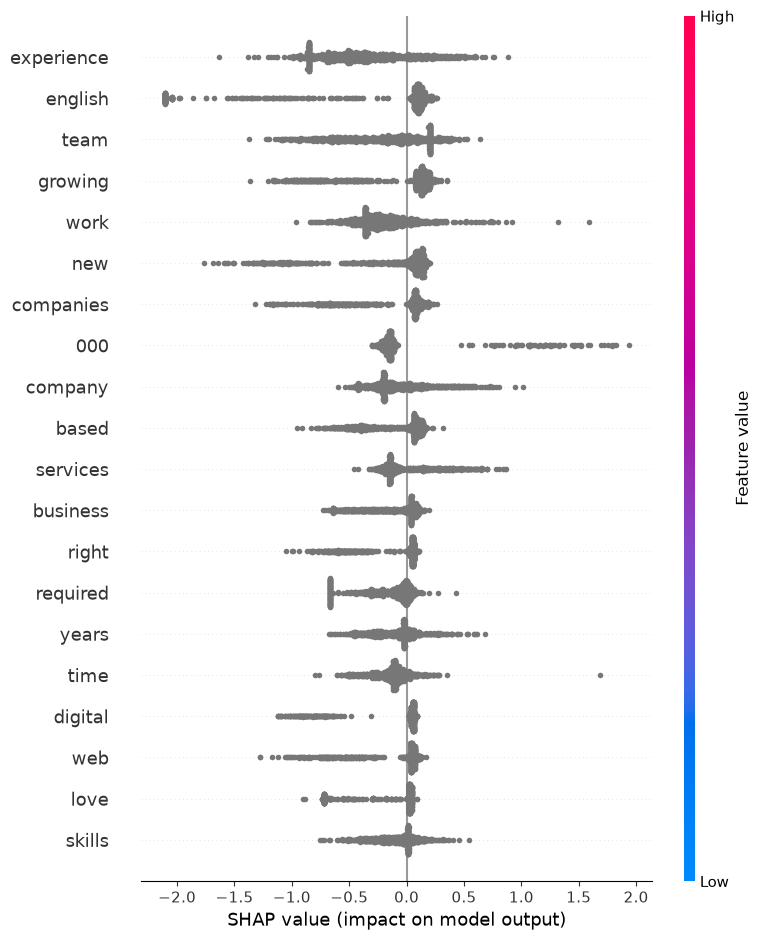

✅ SHAP Summary Plot Saved


In [18]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    explainer.shap_values(X[:1000]),
    X[:1000],
    feature_names=vectorizer.get_feature_names_out(),
    show=False
)

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "artifacts" / "shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ SHAP Summary Plot Saved")

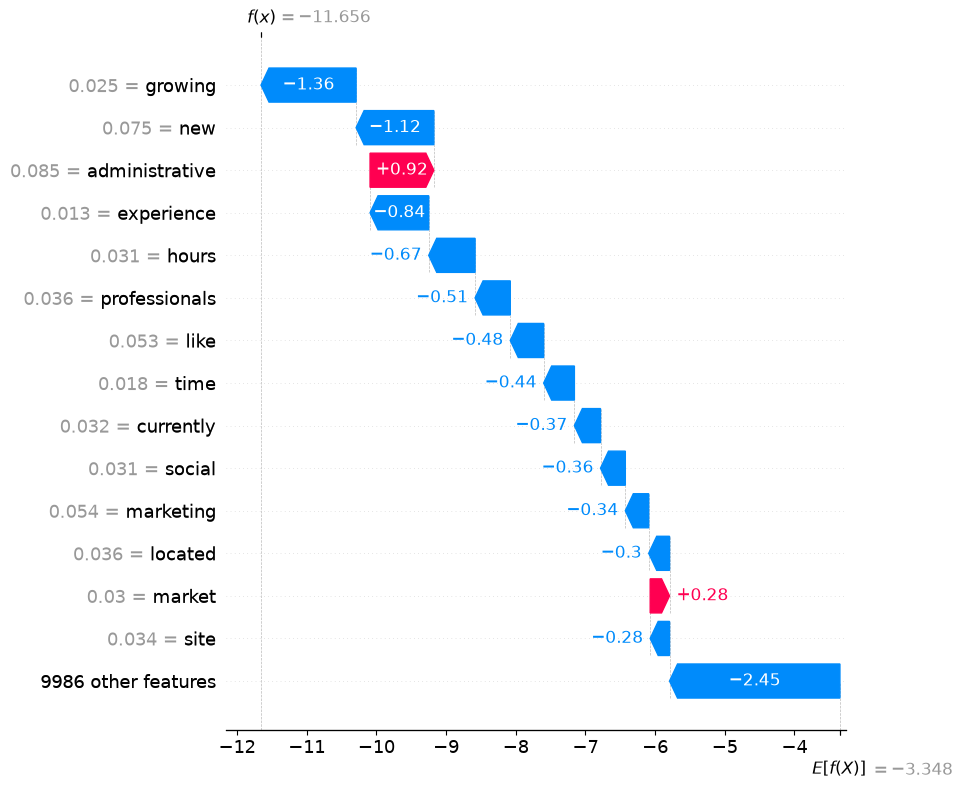

✅ Waterfall Plot Saved


In [19]:
sample_index = 0

sample = X[sample_index]

explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=sample.toarray()[0],
    feature_names=vectorizer.get_feature_names_out()
)

plt.figure(figsize=(12, 8))

shap.plots.waterfall(
    explanation,
    max_display=15,
    show=False
)

plt.savefig(
    PROJECT_ROOT / "artifacts" / "waterfall_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Waterfall Plot Saved")

In [20]:
from src.explainability.shap_explainer import explain_prediction

result = explain_prediction("""
We are hiring a Python Developer with
2 years of experience.
Work from home.
Salary 12 LPA.
""")

result

[{'feature': 'experience', 'impact': -1.3185},
 {'feature': 'developer', 'impact': -1.0154},
 {'feature': 'work home', 'impact': 0.9292},
 {'feature': 'work', 'impact': 0.6934},
 {'feature': 'team', 'impact': 0.4051},
 {'feature': 'salary', 'impact': -0.3543},
 {'feature': 'hiring', 'impact': -0.2929},
 {'feature': 'growing', 'impact': 0.2881},
 {'feature': 'years', 'impact': -0.2395},
 {'feature': 'english', 'impact': 0.212}]

In [21]:
from src.explainability.shap_explainer import explain_prediction

In [24]:
job_description = """
We are hiring a Python Developer with
2 years of experience.
Work from home.
Salary 12 LPA.
"""

top_reasons = explain_prediction(job_description)

top_reasons

[{'feature': 'experience', 'impact': -1.3185},
 {'feature': 'developer', 'impact': -1.0154},
 {'feature': 'work home', 'impact': 0.9292},
 {'feature': 'work', 'impact': 0.6934},
 {'feature': 'team', 'impact': 0.4051},
 {'feature': 'salary', 'impact': -0.3543},
 {'feature': 'hiring', 'impact': -0.2929},
 {'feature': 'growing', 'impact': 0.2881},
 {'feature': 'years', 'impact': -0.2395},
 {'feature': 'english', 'impact': 0.212}]